# Lab 3.04 - Statistical hypothesis testing

In [1]:
# Package imports
# Importing the necessary packages
import numpy as np                                  # Scientific computing
import scipy.stats as stats                         # Statistical tests
import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype
import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation

## Exercise 1 - Navy recruits

The US Navy Recruiting Center knows from the past that recruits' heights are traditionally normally distributed with an average of 69 inches. The recruiting center wants to test whether the average height of this year's recruits exceeds 69 inches. To do this, it takes a random sample of 64 recruits from this year and records their height. The data is in the recruit.csv file.

1. Formulate the null hypothesis and the alternative hypothesis
2. Calculate the p-value
3. Draw a conclusion based on the previous step and answer the research question.

### Answers

- The p-value is 0.0017%
- There is sufficient reason to reject the H0 hypothesis. The p-value is less than 5%. It is almost impossible that the average height of the recruits would actually be 69 inches with the lengths of this sample.

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/recruten.csv',
    sep=";", decimal=",")
df.head()

,Recruit,Height
0,1,74.5
1,2,74.0
2,3,74.6
3,4,69.8
4,5,76.0


In [ ]:
# Stap 1
# H0 = gemiddelde lengte is 69 inch
# H1 = gemiddelde groter dan 69 inch

# Stap 2: significanse level = 5%

# Stap 3

m_sample = df['Height'].mean()

# Stap 4
n = df['Recruit'].count()
mu = 69

m_sample = df['Height'].mean()
s_sample = df['Height'].std()
alpha = 0.05

# Right-tailed t-test => std pop?, gem sample > mu

p_value = stats.t.sf(m_sample, loc = mu, scale = s_sample / np.sqrt(n), df = n-1)
g = stats.t.isf(alpha, loc = mu, scale = s_sample / np.sqrt(n), df = n - 1)
print(p_value, g)

# Stap 5: conclusie
# p < 0.05
# m_sample >>> g
# ==> H0 verwerpen, gemiddelde lengte is groter dan 69 inch

1.7080964227138982e-05 69.62952219716725


## Exercise 2

The amount of rainfall on a certain island over the past 30 years has followed a normal distribution with mean 82.3 cm per year, and standard deviation 15.3. Scientists suspect that global warming has now increased the mean. A hypothesis test, of 5% level of significance is to be carried out to test the suspicion. The average rainfall on the island over the next 5 years will be used for the test.

1. Find the region of rejection for the test
2. What is the probability of making a Type I error?
3. Find the probability of making a Type II error if the mean rainfall on the island has actually increased to 105 cm per year.

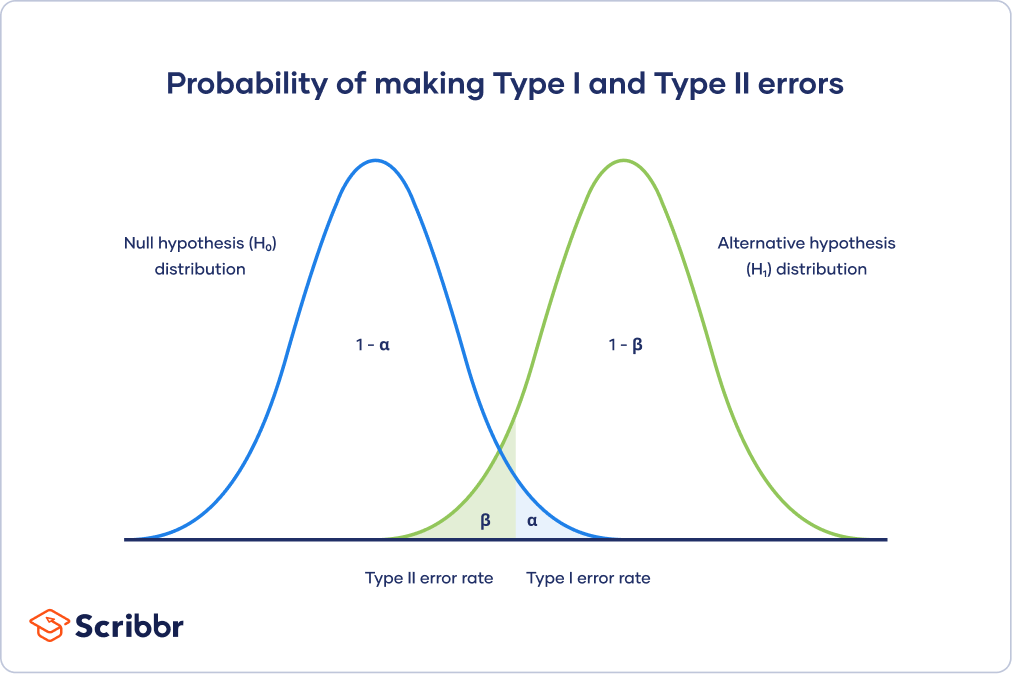

In [ ]:
n = 5
mu = 82.3
sigma = 15.3
alpha = 0.05

# H0 => gemiddelde neerslag van 82.3/jaar
# H1 => gemiddelde neerslag meer dan 82.3/jaar

# right-tailed z => standaardafwijking populatie, n < 30 MAAR: normaal verdeeld!

g = stats.norm.isf(alpha, loc = mu, scale = sigma / np.sqrt(n))
print(g)

# 2, alpha = 5%

93.55469384007576


In [32]:
# Type 2 fout

stats.norm.cdf(g, loc=105, scale = sigma/np.sqrt(n))

np.float64(0.047192073697960024)

### Answers

1. The region of rejection is $\overline{x} \in ]96.8869, +\infty[$
2. The probability of a Type I error (when the original null hypothesis is still correct) is always given by $\alpha$, so for this case 5%.
3. The probability of a Type II error (when $\mu = 105$) $\beta \approx 0.1507$ or 15.0678 %

## Exercise 3

In the past, the time, in minutes for a particular minor medical procedure has been found to have mean 34.2 minutes and standard deviation 2.6. A new method is being considered in the hope that the average time would be shorter. A random sample of 50 procedures using the new method is taken and the mean time is found to be 33.5 minutes.  
Carry out a test at the 5% level of significance to see whether the mean time for the procedure has decreased.

### Answers

- p-value: 0.02847 => p < a: reject H0
- Critical value g ≃ 33.595 => sample mean = 33.500 < g = 33.595: reject H0

In [ ]:
# Stap 1
# H0 => nieuwe procedure duurt 34.2 min
# H1 => nieuwe procedure duurt minder dan 34.2min

# Stap 2
# significance level = 0.05
alpha = 0.05

# Stap 3
m_sample = 33.5

# Stap 4
n = 50
mu = 34.2
sigma = 2.6

# Test: left-tailed z: std pop geweten, n > 30
p_value = stats.norm.cdf(m_sample, loc = mu, scale = sigma / np.sqrt(n))
g = stats.norm.isf(1 - alpha, loc = mu, scale = sigma / np.sqrt(n))

print(m_sample, p_value, g)

# Stap 5: conclusie
# Er is voldoende aanwijzing om H0 te verwerpen
# Voldoende aanwijzing dat de nieuwe procedure significant korter is

33.5 0.028471439030300565 33.595194680088134


## Exercise 4

The stopping distance (in meters) was measured of a truck traveling at 32 km/h under specific conditions. The report stated that under these conditions the maximum permitted stopping distance is 9.15 meters. 
The stopping distance is normally distributed. The values measured are [9.78, 9.33, 9.57, 9.26, 9.45, 9.72]. Do these values suggest that the actual stopping distance is greater than 9.15 meters?
Perform a test with 1% significance level to answer this question. 
Why is a 1% significance level test used in this case instead of a 5% significance level test? 

### Answers
p-value: 0.00381 => p < a: reject H0  
Critical value g ≃ 9.437   
sample mean = 9.5183 > g = 9.437: reject H0

In [34]:
# Stap 1
# H0 => remafstand is 9.15
# H1 => remafstand groter dan 9.15

# Stap 2
alpha = 0.01

# Stap 3
remafstanden = [9.78, 9.33, 9.57, 9.26, 9.45, 9.72]

n = len(remafstanden)
m_sample = np.mean(remafstanden)
mu = 9.15
sigma = np.std(remafstanden, ddof=1)

# right t-test, std pop onbekend
p_value = stats.t.sf(m_sample, loc=mu, scale=sigma/np.sqrt(n), df=n-1)
g = stats.t.isf(alpha, loc=mu, scale=sigma/np.sqrt(n), df=n-1)

print(m_sample, p_value, g)

# Stap 5
# p_value (0.3%) << 1% + m_sample > g => voldoende aanwijzing om H1 te verwerpen
# Remafstand is groter dan 9.15


t_stat, p_val = stats.ttest_1samp(a=remafstanden, popmean=mu, alternative='less')
print("Sample mean        : %.3f" % np.mean(remafstanden))
print("t-score            : %.3f" % t_stat)
print(f"p-value           : {p_val}")


9.518333333333333 0.0038063735174285423 9.437291812438636
Sample mean        : 9.518
t-score            : 4.314
p-value           : 0.9961936264825715


## Exercise 5 - rlanders.csv, revisited

The variable *Money* represents a gross annual salary (×100\\$). We assume this variable has a mean of $\mu = 500$ with standard deviation $\sigma = 98$. If we calculate the sample mean over the entire dataset (do this yourself!), it seems to support our assumptions. But what if we looked at
men and women separately (variable *Gender*)?

First, visualise this case by plotting a kernel density estimate of the variable *Money* over the entire dataset and split up according to *Gender*. Draw a vertical line for the assumed population mean and sample means.

Use an appropriate statistical test to verify the statements below, usinge a significance level of $\alpha = 5\%$. For each statement, calculate the critical value(s) and the $p$-value.

1. The average gross annual salary of men seems higher than the average. Is it also significantly higher?
2. The average gross annual salary of women seems lower. Is it significantly lower?
3. Calculate the region of acceptance for the average gross annual salary for the sample (men and women combined). In this case we want to verify if the sample mean is significantly different from the expected value, but it can be lower or higher.

### Answers

1. Sample mean: $\overline{x} \approx 507.535$, critical value: $g \approx 511.456$, $p \approx 0.1396$. We can **not** reject the null hypothesis. The gross annual income of men in this sample is not significantly higher than expected.
2. Sample mean: $\overline{x} \approx 472.058$, critical value: $g \approx 477.646$, $p \approx 0.0199$. We can reject the null hypothesis. The gross annual income of women in this sample is significantly lower than expected.
3. The acceptance region is the interval $[487.852, 512.148]$.

In [8]:
df = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-en-labs/main/data/rlanders.csv').set_index(['ID'])
# Show the first few records of the Data Frame
df.head()

,Gender,Money,Days,Months,Count,Survey
ID,,,,,,
1,Female,440,29,11,35,3
2,Female,503,23,10,52,3
3,Male,412,16,11,55,3
4,Male,587,25,9,28,5
5,Male,525,30,11,41,4


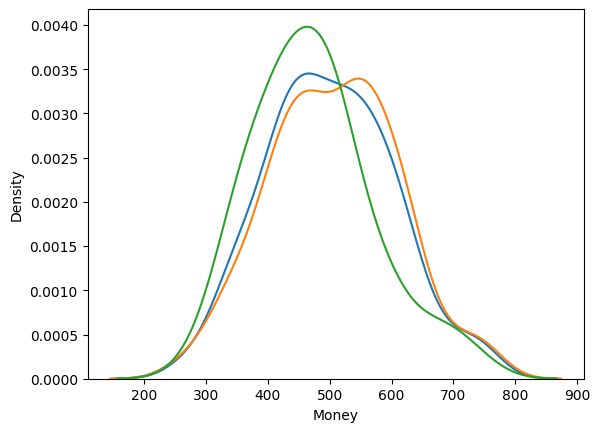

In [14]:
sns.kdeplot(data=df, x='Money')
sns.kdeplot(data=df[df.Gender == 'Male'], x='Money')
sns.kdeplot(data=df[df.Gender == 'Female'], x='Money')
plt.show()

In [ ]:
# Stap 1
# H0 => gemiddelde van de mannen is 500
# H1 => gemiddelde van de mannen is groter dan 500

# Stap 2
alpha = 0.05

# Stap 3
m_sample = df[df.Gender == 'Male']['Money'].mean()

# Stap 4
n = df[df.Gender == 'Male']['Money'].count()
mu = 500
sigma = 98

# Test: right-tailed z: std pop geweten, n > 30
p_value = stats.norm.sf(m_sample, loc = mu, scale = sigma / np.sqrt(n))
g = stats.norm.isf(alpha, loc = mu, scale = sigma / np.sqrt(n))

print(m_sample, p_value, g)

# Stap 5
# 13.96% > 5% + 507 < 511 ==> niet voldoende reden om H0 te verwerpen
# mannen verdienen niet significant meer dan €500

472.0576923076923 0.9801121085373331 522.3538154259782


In [ ]:
# Stap 1
# H0 => gemiddelde van de vrouwen is 500
# H1 => gemiddelde van de vrouwen is groter dan 500

# Stap 2
alpha = 0.05

# Stap 3
m_sample = df[df.Gender == 'Female']['Money'].mean()

# Stap 4
n = df[df.Gender == 'Female']['Money'].count()
mu = 500
sigma = 98

# Test: left-tailed z: std pop geweten, n > 30
p_value = stats.norm.cdf(m_sample, loc = mu, scale = sigma / np.sqrt(n))
g = stats.norm.isf(1 - alpha, loc = mu, scale = sigma / np.sqrt(n))

print(m_sample, p_value, g)

# Stap 5
# 2% kans dat gemiddelde op 472 zou liggen.
# ==> voldoende reden om H0 te verwerpen, vrouwen verdienen significant minder dan €500

472.0576923076923 0.01988789146266692 477.64618457402185


In [24]:
# Acceptance region

n = df.Gender.count()
mu = 500
sigma = 98

g1 = mu - stats.norm.isf(alpha/2) * sigma / np.sqrt(n)
g2 = mu + stats.norm.isf(alpha/2) * sigma / np.sqrt(n)

print("Acceptance region [g1, g2] ≃ [%.3f, %.3f]" % (g1,g2))
if (g1 < m_sample and m_sample < g2):
    print("Sample mean = %.3f is inside acceptance region: do not reject H0" % m_sample)
else:
    print("Sample mean = %.3f is outside acceptance region: reject H0" % m_sample)

Acceptance region [g1, g2] ≃ [487.852, 512.148]
Sample mean = 472.058 is outside acceptance region: reject H0



## Exercise 6 - Binding recommendation on continuation of studies 

It is being said that introducing a “binding recommendation on continuation of studies” (refusing enrollment in the next academic year if a student did not complete a certain level of credits, NL: "bindend studie-advies, BSA") has a positive effect on the study efficiency and success rate. Before the introduction of binding recommendations, the number of completed credits per student per year was 44 with a standard deviation of 6.2. After the introduction, a sample of 72 random students has an average number of completed credits of 46.2.

1. Draw a plot of this case with the probability density for the sample mean, and a vertical line for the population mean and actual sample mean.
2. Test whether there is evidence that the introduction of binding recommendations has improved the success rate among students. Which test do you use in this case? Formulate the null hypothesis and alternative hypothesis.
3. Calculate the critical value for a significance level of $\alpha = 2.5\%$.
4. Calculating the $p$-value.
5. Interpret the meaning of $\alpha$ being 2.5%.


### Answers

1. $g \approx 45.4 < x = 46.2$.

    $x$ is inside the critical region, so we can reject the null hypothesis. Therefore, we can assume that binding recommendation on continuation of studies does increase the success rate.

2. $P(M > 46.2) \approx 0.0013 < \alpha = 0.025$. The probability value is smaller than the significance level, so we can reject the null hypothesis.
3. $\alpha$ represents the probability of rejecting a true null hypothesis $H_0$. In other words, there is a 2.5% chance that you wrongly conclude that the success rate has increased.

In [25]:
n = 72
mu = 44
sigma = 6.2
m_sample = 46.2
alpha = 0.025

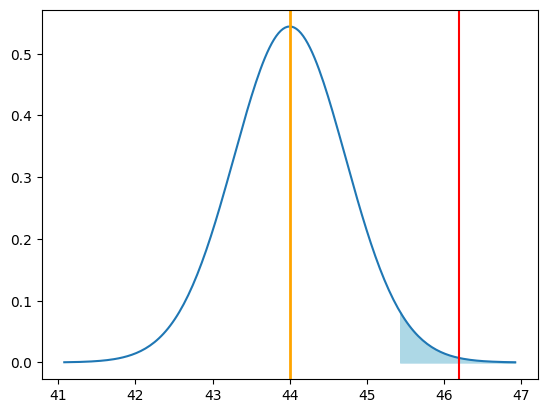

In [30]:
dist_x = np.linspace(mu - 4 * sigma/np.sqrt(n), mu + 4 * sigma/np.sqrt(n), num=201)
dist_y = stats.t.pdf(dist_x, loc = mu, scale = sigma/np.sqrt(n), df = n - 1)
fig, dplot = plt.subplots(1, 1)

dplot.plot(dist_x, dist_y)
dplot.axvline(mu, color="orange", lw=2)
dplot.axvline(m_sample, color="red")
dplot.fill_between(dist_x, 0, dist_y, where=dist_x >= g, color='lightblue')

In [ ]:
# Stap 1
# H0 => gemiddelde ligt op 44 studiepunten
# H1 => gemiddelde groter dan 44 studiepunten

# Stap 2
alpha = 0.025

# Stap 3
m_sample = 46.2

# Stap 4
n = 72
mu = 44
sigma = 6.2
m_sample = 46.2
alpha = 0.025

# rigt-tailed z-test (n > 30, sigma gegeven)
p_value = stats.norm.sf(m_sample, loc=mu, scale=sigma/np.sqrt(n))
g = stats.norm.isf(alpha, loc=mu, scale=sigma/np.sqrt(n))

print(m_sample, p_value, g)

# Stap 5
# Kans < 0.013%
# m_sample > g ==> voldoende aanwijzing om H₀ te verwerpen
# de studenten verwerpen meer credits dan 64

46.2 0.001302346104883357 45.432100618494665


## Vraag 7

De droogtijd van een type verf is normaal verdeeld met een gemiddelde waarde van 75 min en een standaardafwijking van 9 min. Chemici hebben een nieuw additief voorgesteld om de gemiddelde droogtijd te verkorten. Er wordt aangenomen dat de droogtijden met dit additief normaal verdeeld zullen blijven met een standaardafwijking van 9 min. Vanwege de kosten die met het additief gepaard gaan, vragen we ons af of de droogtijd significant korter wordt.

1. Welke hypothesetoets ga je toepassen om deze onderzoeksvraag te beantwoorden? Wees zo specifiek mogelijk!
2. Formuleer de nulhypothese en de alternatieve hypothese
3. Bereken de gepaste toetsingsgrootheid (teststatistiek) voor deze toets. Geef het symbool en de waarde
4. Bereken de p-waarde
5. Trek een besluit op basis van de vorige stap en formuleer een antwoord op de onderzoeksvraag.
6. Stel dat er een Type II fout wordt gemaakt en dat de gemiddelde droogtijd effectief daalde tot 72 min. Wat is de kans op een Type II fout?


In [36]:
waarden = [82.5, 70.8, 88.9, 69.8, 61.5, 72.8, 81.1, 81.5, 65.2, 62.3, 68.7, 67.2, 66.0,  63.8,  65.9, 79.7, 77.0,  62.3, 70.5, 73.4, 83.4, 72.7, 67.5, 67.2, 72.6, 72.9, 79.6, 83.7,  73.4, 74.3, 73.9, 79.8, 79.4, 85.3, 65.6]

# 1. z-test (mu & sigma, normaal verdeeld, n > 30)

# 2. 
# H0 => droogtijd is 75 min
# H1 => droogtijd is minder dan 75 min

# 3.
m_sample = np.mean(waarden)
print(m_sample)

# 4.
n = len(waarden)
mu = 75
sigma = 9
alpha = 0.05

p_value = stats.norm.cdf(m_sample, loc=mu, scale=sigma/np.sqrt(n))
g = stats.norm.isf(1 - alpha, loc=mu, scale=sigma/np.sqrt(n))

print(m_sample, p_value, g)
# 5.

# p_value >> 5%, droogtijd niet significant groter geworden
# m_sample (73.2) > g (72.5)

# 6.
print(stats.norm.sf(g, loc=72, scale=sigma/np.sqrt(n)))

73.2057142857143
73.2057142857143 0.1191075843699731 72.4977209257974
0.3717685328190658
